This notebook has been inspired by the book from Sebastian Raschka "Python Machine Learning".

## Multi Layer Perceptron

We are going in this notebook to code a multi layer perceptron from scratch. A multi layer perceptron is a sequence of matrix computation, each followed by a non- linear function. In this notebook we are going to use as non linear function the sigmoid - even if currently ReLu is a more used function. We are going to show how to code a simple neural network.



### Exercise 1 - Define a function that compute the sigmoid and plot the function

The sigmoid is defined as:

$$
\phi(z) = \frac{1}{1+e^{-z}}
$$

In [1]:
import numpy as np

def sigmoid(z):
    ## compute the sigmoid
    return 1.0/(1+np.exp(-z))

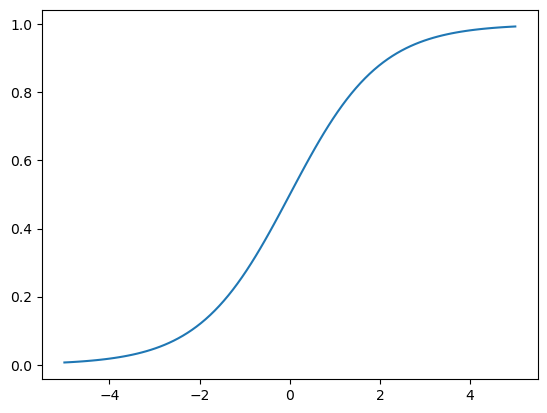

In [43]:
x = np.linspace(-5,5,100)
y = [sigmoid(z) for z in x]

import matplotlib.pyplot as plt
%matplotlib inline

plt.plot(x,y)
plt.show()

### Exercise 2 - one hot function

Write a function that takes in input a list of values and returns the one_hot values of them.

In [3]:
def one_hot(y):
    n_classes = np.sort(np.unique(y))
    values = {n_class: i for i, n_class in enumerate(n_classes)}
    onehot = np.zeros((len(y), len(n_classes)))
    for idx, val in enumerate(y):
        onehot[ idx, values[val]] = 1.
    return onehot

In [4]:
assert (one_hot([1,2]) == np.array([[1,0], [0., 1]]) ).all()
assert (one_hot([2,1]) == np.array([[0,1], [1., 0]]) ).all()
assert (one_hot([2, 1,2,3,1, 4]) == np.array([[0.,1.,0.,0.], [1,0.,0.,0.], [0.,1.,0., 0], [0, 0, 1, 0], [1.,0.,0.,0.], [0., 0., 0., 1.]])).all()

### Exercise 3 - Cost function - logistic cost function

We are going to use as cost function the logistic cost function (with no regularization). We are also going to normalize the logistic cost functionwith respect to the number of values we are considering, to be able to evaluate it on datasets of different lenghts.

$$
C =-\frac{1}{n} \sum_{1}^{n}{ \bigg( y^{i}*\log(f(x^{i}))+(1-y^{i}) *\log(1-f(x^{i})) \bigg)}
$$

where

- n isthe number of datapoints
- $y^{i}$ is the label for the $i^{th}$ element
- $f$ is the prediction function
- $x^{i}$ is the $i^{th}$ element of the dataset


In [5]:
import numpy as np

def cost_function(y_label, prediction):
    term1 = y_label * (np.log(prediction))
    term2 = (1. - y_label) * np.log(1. - prediction)
    return -np.sum(term1 + term2)/len(y_label)



In [6]:
assert np.abs(cost_function(np.array([[1,0]]), np.array([[0.9,0.1]])) - 0.21072103131565256) < 0.000001
assert np.abs(cost_function(np.array([[1,0,], [0, 1]]), np.array([[0.999,0.1], [0.5, 0.5]])) - 0.7463276885556502) < 0.000001

###  Exercise 4 - Forward propagation 

In the following we are going to consider a multi-layer perceptron having only one hidden layer of a certain size. The non-linear function is going to be the sigmoid.

Let X be data. The algorithm to compute the forward pass is the following:



$$z_{h} = X*w_{h} + b_{h} $$
$$a_{h} = \phi(z_{h})$$
$$z_{out} = a_{h}*w_{out} + b_{out}$$
$$a_{out} = \phi(z_{out})$$

Function should return values for $z_{h}, a_{h}, z_{out}, a_{out}$.

In [7]:
def forward(X, w_h, b_h, w_out, b_out, print_shapes=False):
    z_h = np.dot(X, w_h) + b_h
    a_h = sigmoid(z_h)
    
    z_out = np.dot(a_h, w_out) + b_out
    a_out = sigmoid(z_out)
    
    if print_shapes:
        print(f"dim X: {np.array(X).shape}")
        print(f"dim w_h: {np.array(w_h).shape}")
        print(f"dim b_h: {np.array(b_h).shape}")
        print(f"dim z_h: {np.array(z_h).shape}")
        print(f"dim a_h: {np.array(a_h).shape}")
        print(f"dim w_out: {np.array(w_out).shape}")
        print(f"dim b_out: {np.array(b_out).shape}")
        print(f"dim z_out: {np.array(z_out).shape}")
        print(f"dim a_out: {np.array(a_out).shape}")

    return z_h, a_h, z_out, a_out

In [8]:
forward_X_test = [[1,0,1]]
forward_wh_test = [[0,1], [1,0], [1,1]]
forward_bh_test = [1,1]
forward_wout_test = [[1,4,5], [2,-1, -1]]
forward_bout_test = [1,2,-1]

t1, t2, t3, t4 = forward(forward_X_test, forward_wh_test,forward_bh_test, forward_wout_test, forward_bout_test,
                        print_shapes=True)

assert (t1 == np.array([[2,3]])).all()
assert (t2 - np.array([[0.88079708, 0.95257413]]) < 0.00001).all()
assert (t3 - np.array([[3.78594533 ,4.57061419, 2.45141126]]) < 0.000001).all()
assert (t4 - np.array([[0.99987661, 0.99908895, 0.99752738]]) < 0.00001).all()

dim X: (1, 3)
dim w_h: (3, 2)
dim b_h: (2,)
dim z_h: (1, 2)
dim a_h: (1, 2)
dim w_out: (2, 3)
dim b_out: (3,)
dim z_out: (1, 3)
dim a_out: (1, 3)


### Exercise 5 - Back propagation

We are going to need before being able to train a neural network, the back propagation step. In this step we are going to compute the error the model is doing with respect to the true label and backpropagate this information to every layer. Then we will update the weight of each layer with the information from the gradient.

We are going to compute:


$$\delta_{out} = a_{out} - y$$
$$\frac{\partial \phi(z_{h})}{\partial z_{h}} = a_{h}*(1-a_{h})$$
$$\delta_{h} = (\delta_{out} w_{out}^{T})*(a_{h}*(1-a_{h}))$$
$$\nabla(w_{h}) = X^{T} \delta_{h}$$
$$\nabla(b_{h}) = \sum{\delta_{h}}$$
$$\nabla(w_{out}) = a_{h}^{T}\delta_{out}$$
$$\nabla(b_{out}) = \sum{\delta_{out}}$$


It should return the values of


$$\nabla(w_{h})$$
$$\nabla(b_{h})$$
$$\nabla(w_{out})$$
$$\nabla(b_{out})$$


In [9]:
def backpropagation(X, y, z_h, a_h, z_out, a_out, w_out, print_shapes=False):
    delta_out = a_out - y

    sigmoid_derivative_h = a_h * (1. - a_h)

    delta_h = (np.dot(delta_out, w_out.T) *
               sigmoid_derivative_h)

    grad_w_h = np.dot(X.T, delta_h)
    grad_b_h = np.sum(delta_h, axis=0)

    grad_w_out = np.dot(a_h.T, delta_out)
    grad_b_out = np.sum(delta_out, axis=0)
    if print_shapes:
        print(f"dim delta_out: {np.array(delta_out).shape}")
        print(f"dim w_out.T: {np.array(w_out).T.shape}")
        print(f"dim np.dot(delta_out, w_out.T): {np.array(np.dot(delta_out, w_out.T)).shape}")
        print(f"dim sigmoid_derivative_h: {np.array(sigmoid_derivative_h).shape}")
        print(f"dim grad_w_out: {np.array(grad_w_out).shape}")
        print(f"dim grad_b_out: {np.array(grad_b_out).shape}")
        print('\n')
        print(f"dim X.T: {np.array(X.T).shape}")
        print(f"dim delta_h: {np.array(delta_h).shape}")
        print(f"dim grad_w_h: {np.array(grad_w_h).shape}")
        print(f"dim grad_b_h: {np.array(grad_b_h).shape}")
    return grad_w_h, grad_b_h, grad_w_out, grad_b_out

In [10]:
g1, g2, g3, g4 = backpropagation(np.array(forward_X_test), [0,1,0], t1, t2, t3, t4, np.array(forward_wout_test),
                                print_shapes=True)


assert np.abs((g1 - np.array([[0.58168091, 0.04721922],
 [0.  ,       0.        ],
 [0.58168091, 0.04721922]]))).sum() < 0.0001
assert np.abs((g2 - np.array([0.58168091, 0.04721922]))).sum() < 0.0001
assert np.abs((g3 - np.array([[ 0.86125738, -0.00902424,  0.81091868],
 [ 0.93144212, -0.00975964,  0.87700127]]))).sum() < 0.0001
assert np.abs((g4 - np.array([ 0.97781589, -0.01024554,  0.92066459]))).sum() < 0.0001


dim delta_out: (1, 3)
dim w_out.T: (3, 2)
dim np.dot(delta_out, w_out.T): (1, 2)
dim sigmoid_derivative_h: (1, 2)
dim grad_w_out: (2, 3)
dim grad_b_out: (3,)


dim X.T: (3, 1)
dim delta_h: (1, 2)
dim grad_w_h: (3, 2)
dim grad_b_h: (2,)


### Exercice 6 - Putting all together

We are going to create a class called MultiLayerPerceptron that takes as input in the init:

- the number of features of the dataset X $n_{features}$
- the number of hidden neurons $n_{hidden}$
- the number of output neurons $n_{output}$ (number of unique labels in target)

We are going to initiate as class variables:
- bias vector $b_{h}$ as a set of zeros of length $n_{hidden}$
- matrix $w_{h}$ as a random normal matrix with size $(n_{features}, n_{hidden})$
- bias vector $b_{out}$ as a set of zeros of length $n_{output}$
- matrix $w_{out}$ as a random normal matrix with size $(n_{hidden}, n_{output})$

Then we will integrate the two functions forward and backprop by using the class variables instead of having a static function. We are going to use both in the train method

In [11]:
import random


class MultiLayerPerceptron:
    def __init__(self, n_features, n_hidden, n_output):
        self.b_h = np.zeros(n_hidden)
        self.w_h = np.random.normal(loc=0.0, scale=0.1,
                                      size=(n_features, n_hidden))

        # weights for hidden -> output
        self.b_out = np.zeros(n_output)
        self.w_out = np.random.normal(loc=0.0, scale=0.1,
                                        size=(n_hidden, n_output))
        
    def forward(self, X):
        z_h = np.dot(X, self.w_h) + self.b_h
        a_h = sigmoid(z_h)
    
        z_out = np.dot(a_h, self.w_out) + self.b_out
        a_out = sigmoid(z_out)

        return z_h, a_h, z_out, a_out
    
   
    
    
    def backprop(self, X_batch, y_batch, z_h, a_h, z_out, a_out):
        delta_out = a_out - y_batch

        sigmoid_derivative_h = a_h * (1. - a_h)

        delta_h = (np.dot(delta_out, self.w_out.T) *
                   sigmoid_derivative_h)

        grad_w_h = np.dot(X_batch.T, delta_h)
        grad_b_h = np.sum(delta_h, axis=0)

        grad_w_out = np.dot(a_h.T, delta_out)
        grad_b_out = np.sum(delta_out, axis=0)

        return grad_w_h, grad_b_h, grad_w_out, grad_b_out

    def train(self, X_train, y_train, X_val, y_val, epochs, batch_size, learning_rate):
        epoch_loss_train = []
        epoch_loss_val = []
        batch_loss = []
        
        for idx_epoch in range(epochs):
            # iterate over minibatches
            indices = np.arange(X_train.shape[0])
            batch_num = 1
            random.shuffle(indices)
            for start_idx in range(0, indices.shape[0] - batch_size + 1, batch_size):
                batch_idx = indices[start_idx:start_idx + batch_size]

                X_batch = X_train[batch_idx]
                y_batch = y_train[batch_idx]
                
                # forward propagation
                z_h, a_h, z_out, a_out = self.forward(X_batch)
                
                batch_cost = cost_function(y_batch, a_out)
                batch_num += 1
                
                batch_loss.append(batch_cost)
                grad_w_h, grad_b_h, grad_w_out, grad_b_out = self.backprop(X_batch, y_batch, z_h, a_h, z_out, a_out)

                # Regularization and weight updates
                #delta_w_h = (grad_w_h + reg_rate*self.w_h)
                #delta_b_h = grad_b_h # bias is not regularized
                self.w_h -= learning_rate * grad_w_h
                self.b_h -= learning_rate * grad_b_h

                #delta_w_out = (grad_w_out + reg_rate*self.w_out)
                #delta_b_out = grad_b_out  # bias is not regularized
                self.w_out -= learning_rate * grad_w_out
                self.b_out -= learning_rate * grad_b_out
            
            _, _, _, a_out = self.forward(X_train)
            
            cost = cost_function(y_train, a_out)
            self.predict(X_val)
            
            _, _, _, a_out_val = self.forward(X_val)
            cost_val = cost_function(y_val, a_out_val)
            epoch_loss_train.append(cost)
            epoch_loss_val.append(cost_val)
            print(f'Epoch {idx_epoch}: train {cost} - eval {cost_val}')
        return epoch_loss_train, epoch_loss_val, batch_loss
    
    def predict(self, X):
        _, _, _, prediction = self.forward(X)
        return np.argmax(prediction, axis=1)
    
    def predict_proba(self, X):
        _, _, _, prediction = self.forward(X)
        return prediction

### Import the datasets

We are going to use the digits dataset from sklearn. We will build a train, validation and test set.

In [12]:
!pip install scikit-learn
%pip install scikit-learn

from sklearn.datasets import load_digits

Note: you may need to restart the kernel to use updated packages.


In [13]:
digits = load_digits()

In [14]:
X = digits.data
y = one_hot(digits.target)

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15)

### Exercice 7 - training a classifier

Create a new object nn with the correct dimension for values $n_{features}$ and $n_{output}$. You can choose the number of hidden neurons you want to use.

Call the *train* method with different epochs, batch_size and learning_rate.

In [16]:
nn_code = MultiLayerPerceptron(X_train.shape[1], 30, n_output=10)

In [17]:
epoch_value, epoch_loss_val, batch_value = nn_code.train(X_train, y_train, X_val, y_val, epochs=150, batch_size=16, learning_rate=3*1e-4)

Epoch 0: train 3.4772634138892062 - eval 3.471860300561645
Epoch 1: train 3.2288671011285306 - eval 3.2241461323420255
Epoch 2: train 3.1596918106571903 - eval 3.1593977133665585
Epoch 3: train 3.100970701874844 - eval 3.1028748656482468
Epoch 4: train 3.048610962611859 - eval 3.046804651647824
Epoch 5: train 2.997269053359487 - eval 2.99009256633675
Epoch 6: train 2.9446172243580646 - eval 2.9329665082591223
Epoch 7: train 2.886253323164446 - eval 2.8710509298168563
Epoch 8: train 2.8235855071422638 - eval 2.8037749057525434
Epoch 9: train 2.7636257792867682 - eval 2.739572202904568
Epoch 10: train 2.702941865288703 - eval 2.6760128661727274
Epoch 11: train 2.643467080747802 - eval 2.6172045537473507
Epoch 12: train 2.5867772861213156 - eval 2.55655379058897
Epoch 13: train 2.5327339341112642 - eval 2.4995571521202935
Epoch 14: train 2.480493569328861 - eval 2.447411013717515
Epoch 15: train 2.42928255136413 - eval 2.396536214995602
Epoch 16: train 2.3787652945474633 - eval 2.34544311

### Exercice 8 - compute accuracy metrics for train, test and valuation

In [18]:
(np.argmax(y_train, axis=1) == np.argmax(nn_code.forward(X_train)[3], axis=1)).sum()/len(X_train)

0.9905385735080058

In [19]:
(np.argmax(y_test, axis=1) == np.argmax(nn_code.forward(X_test)[3], axis=1)).sum()/len(X_test)

0.9833333333333333

In [20]:
(np.argmax(y_val, axis=1) == np.argmax(nn_code.forward(X_val)[3], axis=1)).sum()/len(X_val)

0.9670781893004116

### Exercice 9 - show examples of mislabelled images for training, valuation and test sets

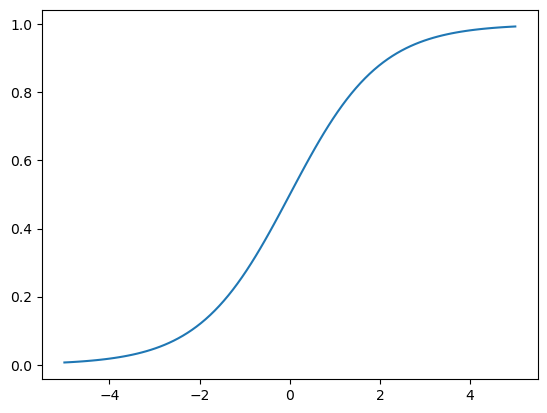

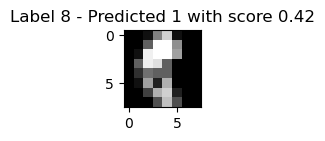

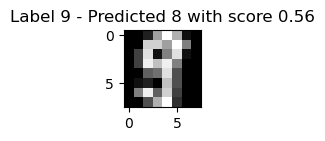

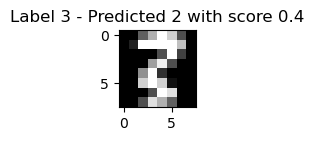

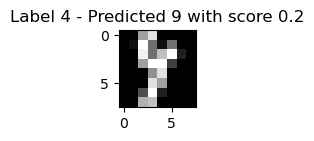

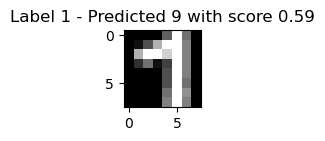

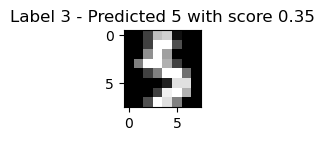

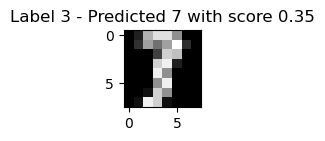

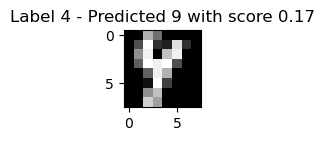

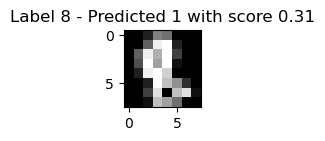

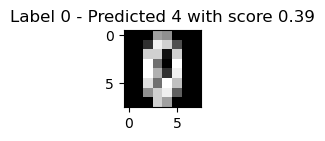

In [21]:
import matplotlib.pyplot as plt
%matplotlib inline

train_predictions = nn_code.predict_proba(X_train)
count = 0
for i, val in enumerate(train_predictions):
    if np.argmax(val) != np.argmax(y_train[i]):
        image = np.reshape(X_train[i], (8, 8))
        plt.figure(figsize=(1,1))
        plt.imshow(image, cmap='gray')
        score = int(np.max(val)*100)/100
        plt.title(f'Label {np.argmax(y_train[i])} - Predicted {np.argmax(val)} with score {score}')
        plt.show()
        count += 1
    if count == 10:
        break

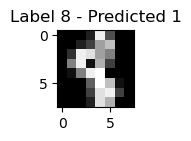

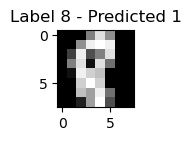

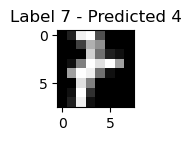

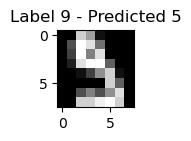

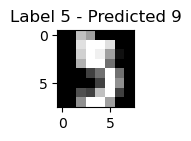

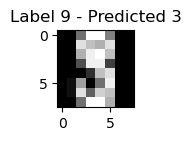

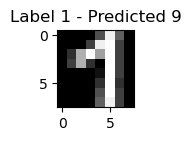

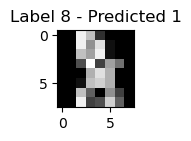

In [22]:
import matplotlib.pyplot as plt
%matplotlib inline

test_predictions = np.argmax(nn_code.forward(X_val)[3], axis=1)
for i, val in enumerate(test_predictions):
    if val != np.argmax(y_val[i]):
        image = np.reshape(X_val[i], (8, 8))
        plt.figure(figsize=(3,1))
        plt.imshow(image, cmap='gray')
        plt.title(f'Label {np.argmax(y_val[i])} - Predicted {val}')
        
        plt.show()

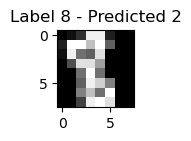

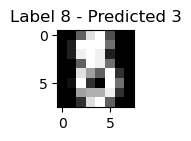

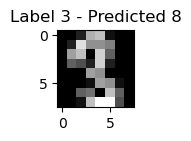

In [23]:
import matplotlib.pyplot as plt
%matplotlib inline

test_predictions = np.argmax(nn_code.forward(X_test)[3], axis=1)
for i, val in enumerate(test_predictions):
    if val != np.argmax(y_test[i]):
        image = np.reshape(X_test[i], (8, 8))
        plt.figure(figsize=(3,1))
        plt.imshow(image, cmap='gray')
        plt.title(f'Label {np.argmax(y_test[i])} - Predicted {val}')
    
        plt.show()

### Exercice 9 - plot training graphs

Plot a graph having epoch loss for train and validation sets. 

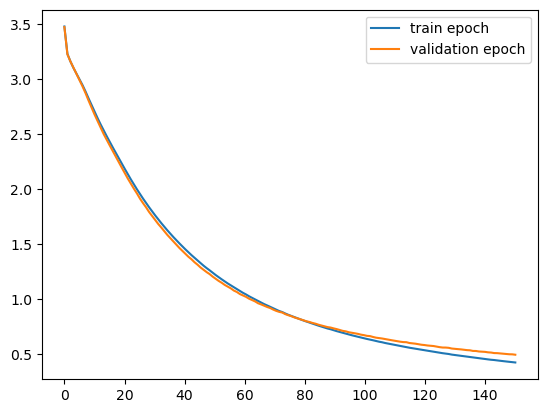

In [24]:
x_epoch = np.linspace(0, len(epoch_value), len(epoch_value))
plt.plot(x_epoch, epoch_value, label='train epoch')
plt.plot(x_epoch, epoch_loss_val, label='validation epoch')
plt.legend()
plt.show()

Add to the plot a graph having epoch loss for batch loss. 

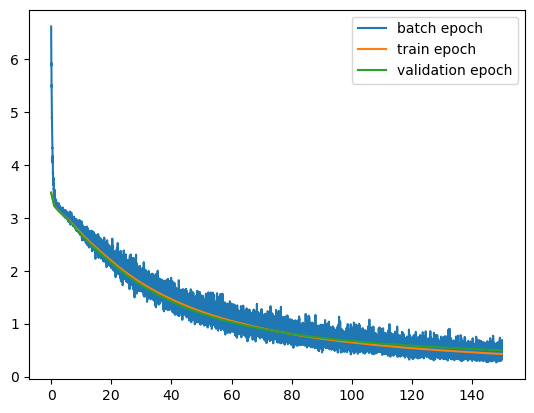

In [25]:
x_epoch = np.linspace(0, len(epoch_value), len(epoch_value))
batch_epoch = np.linspace(0, len(epoch_value), len(batch_value))
plt.plot(batch_epoch, batch_value, label='batch epoch')
plt.plot(x_epoch, epoch_value, label='train epoch')
plt.plot(x_epoch, epoch_loss_val, label='validation epoch')
plt.legend()
plt.show()

# Using pytorch

By using pytorch documentation, replicate what has been done from scratch.

Change the definition of the network to see what works better.

In [26]:
import torch
from torch import nn
import random

In [27]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(64, 40),
            nn.ReLU(),
            nn.Linear(40,10),
            nn.ReLU(),
            nn.Linear(10,10)
            )
        
    def forward(self, x):
        logits = self.model(x)
        return logits
    
       
    def train(self, X_train, y_train, X_val, y_val, epochs, batch_size, learning_rate):
        epoch_loss_train = []
        epoch_loss_val = []
        batch_loss = []
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.SGD(self.model.parameters(), lr=learning_rate)  
        for idx_epoch in range(epochs):
            # iterate over minibatches
            indices = np.arange(X_train.shape[0])
            random.shuffle(indices)
            batch_num = 1
            for start_idx in range(0, indices.shape[0] - batch_size + 1, batch_size):
                batch_idx = indices[start_idx:start_idx + batch_size]
                optimizer.zero_grad()

                X_batch = torch.from_numpy(X_train[batch_idx])
                y_batch = torch.from_numpy(y_train[batch_idx])

                outputs = self.model(X_batch.float())
                loss = criterion(outputs, y_batch)
                
                loss.backward()
                optimizer.step()
                batch_loss.append(loss.item())
            
            pred_train = self.model(torch.from_numpy(X_train).float())
            loss_train = criterion(pred_train, torch.from_numpy(y_train).float())
            
            pred_val = self.model(torch.from_numpy(X_val).float())
            loss_val = criterion(pred_val, torch.from_numpy(y_val).float())
            print(f'Loss: {loss.item()} - {loss_val.item()}')
            epoch_loss_train.append(loss_train.item() )
            epoch_loss_val.append(loss_val.item() )

        return epoch_loss_train, epoch_loss_val, batch_loss
    
    def compute_accuracy(self, X_values, y_values):
        pred = torch.argmax(self.model(torch.from_numpy(X_values).float()), 1)
        return ((pred.detach().numpy() == np.argmax(y_values, axis=1)).sum()/len(pred))

In [28]:
torch_nn = NeuralNetwork()

In [29]:
loss_train, loss_val, batch_loss = torch_nn.train(X_train, y_train, X_val, y_val, 150, 16, 1e-3)

Loss: 2.2106099501252174 - 2.1814510822296143
Loss: 2.021021753549576 - 2.0536575317382812
Loss: 2.1589858382940292 - 1.9341233968734741
Loss: 1.965039223432541 - 1.82846999168396
Loss: 1.5801637023687363 - 1.7232294082641602
Loss: 1.9083665236830711 - 1.629683494567871
Loss: 1.3847680911421776 - 1.5372917652130127
Loss: 1.4082764983177185 - 1.4543988704681396
Loss: 1.6512534730136395 - 1.3676704168319702
Loss: 1.3141392543911934 - 1.2888991832733154
Loss: 1.3317781426012516 - 1.211791753768921
Loss: 1.3196675069630146 - 1.1344374418258667
Loss: 1.0665244366973639 - 1.055293083190918
Loss: 0.9653715547174215 - 0.9806445837020874
Loss: 0.8961885645985603 - 0.9125399589538574
Loss: 0.584993785712868 - 0.8394350409507751
Loss: 0.9401474450714886 - 0.7703976631164551
Loss: 0.592989657074213 - 0.7002984881401062
Loss: 0.6315225353464484 - 0.6429815888404846
Loss: 0.7085077211959288 - 0.5897988677024841
Loss: 0.6280452627688646 - 0.5463549494743347
Loss: 0.43282571667805314 - 0.5066690444946

### Exercice 10 

Evaluate the accuracy for train, evaluation and test set. Add a method compute_accuracy to the class NeuralNetwork

In [30]:
print(f'Accuracy for train set: {torch_nn.compute_accuracy(X_train, y_train)}')

Accuracy for train set: 0.9934497816593887


In [31]:
print(f'Accuracy for validation set: {torch_nn.compute_accuracy(X_val, y_val)}')

Accuracy for validation set: 0.9670781893004116


In [32]:
print(f'Accuracy for test set: {torch_nn.compute_accuracy(X_test, y_test)}')

Accuracy for test set: 0.95


### Exercice 11

Plot the graphs of training for both training and evaluation set.

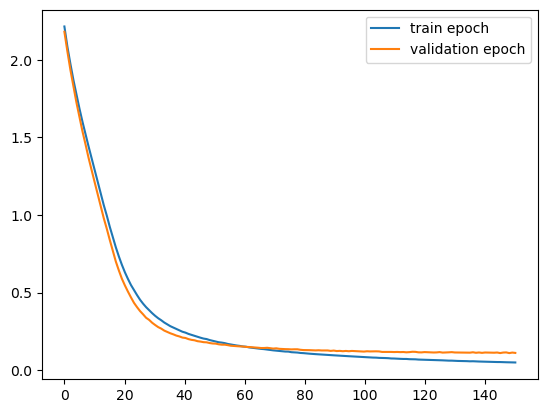

In [33]:
x_epoch = np.linspace(0, len(loss_train), len(loss_train))
plt.plot(x_epoch, loss_train, label='train epoch')
plt.plot(x_epoch, loss_val, label='validation epoch')
plt.legend()
plt.show()

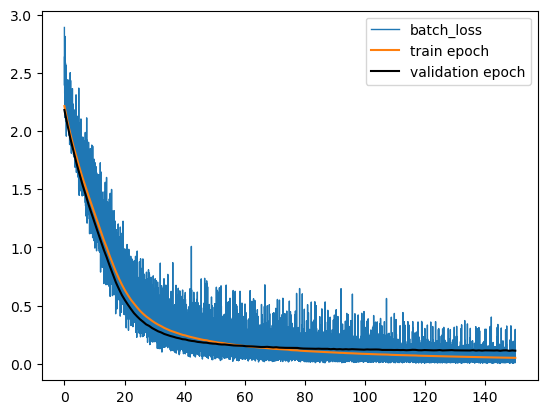

In [34]:
x_epoch = np.linspace(0, len(loss_train), len(loss_train))
batch_epoch = np.linspace(0, len(loss_train), len(batch_loss))
plt.plot(batch_epoch, batch_loss, label='batch_loss', linewidth=1)
plt.plot(x_epoch, loss_train, label='train epoch')
plt.plot(x_epoch, loss_val, label='validation epoch', color='black')
plt.legend()
plt.show()

### Exercice 12 

Find the set of images that are wrongly classified by both models.

In [35]:
pred_nn_model = nn_code.predict(X_test)
pred_pytorch = torch.argmax(torch_nn.model(torch.from_numpy(X_test).float()), 1)

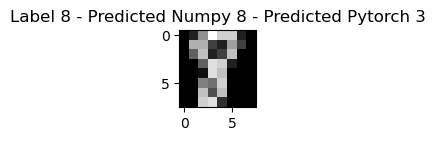

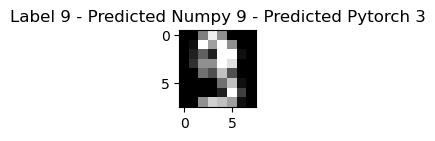

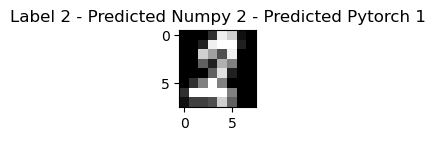

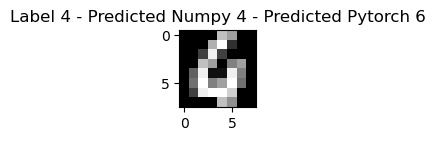

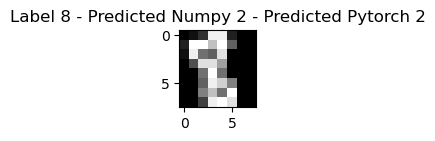

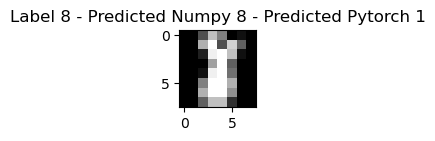

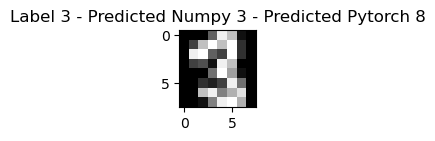

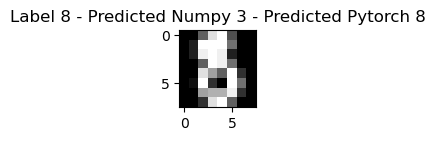

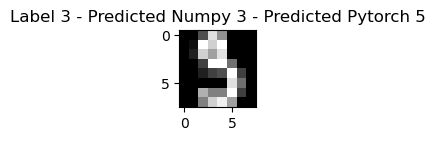

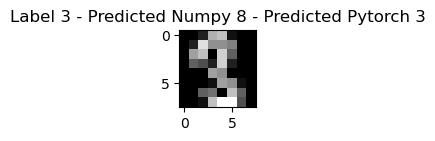

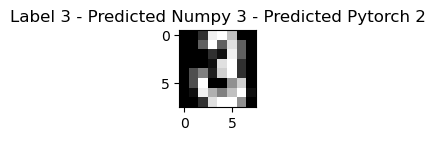

In [36]:
for i, true_label in enumerate(y_test):
    pred_1 = pred_nn_model[i]
    pred_2 = pred_pytorch[i].item()
    true_label = np.argmax(true_label)
    if pred_1 != true_label or pred_2 != true_label:
        image = np.reshape(X_test[i], (8, 8))
        plt.figure(figsize=(3,1))
        plt.imshow(image, cmap='gray')
        plt.title(f'Label {true_label} - Predicted Numpy {pred_1} - Predicted Pytorch {pred_2}')
    
        plt.show()
        

### Exercice 13 - Use a convolutional neuronal network instead of a linear network (optional)

In [37]:
class ConvNetwork(nn.Module):
    def __init__(self):
        super(ConvNetwork, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 10, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(10, 10, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(640, 10)
            )
        
    def forward(self, x):
        logits = self.model(x)
        return logits
    
       
    def train(self, X_train, y_train, X_val, y_val, epochs, batch_size, learning_rate):
        epoch_loss_train = []
        epoch_loss_val = []
        batch_loss = []
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.SGD(self.model.parameters(), lr=learning_rate)  
        for idx_epoch in range(epochs):
            # iterate over minibatches
            indices = np.arange(X_train.shape[0])
            random.shuffle(indices)
            batch_num = 1
            for start_idx in range(0, indices.shape[0] - batch_size + 1, batch_size):
                batch_idx = indices[start_idx:start_idx + batch_size]
                optimizer.zero_grad()

                X_batch = torch.from_numpy(X_train[batch_idx])
                y_batch = torch.from_numpy(y_train[batch_idx])
                
                self.forward(X_batch.float())
                
                outputs = self.model(X_batch.float())
                loss = criterion(outputs, y_batch)
                
                loss.backward()
                optimizer.step()
                batch_loss.append(loss.item())
            
            pred_train = self.model(torch.from_numpy(X_train).float())
            loss_train = criterion(pred_train, torch.from_numpy(y_train).float())
            
            pred_val = self.model(torch.from_numpy(X_val).float())
            loss_val = criterion(pred_val, torch.from_numpy(y_val).float())
            print(f'Loss: {loss.item()} - {loss_val.item()}')
            epoch_loss_train.append(loss_train.item() )
            epoch_loss_val.append(loss_val.item() )

        return epoch_loss_train, epoch_loss_val, batch_loss
    
    def compute_accuracy(self, X_values, y_values):
        pred = torch.argmax(self.model(torch.from_numpy(X_values).float()), 1)
        return ((pred.detach().numpy() == np.argmax(y_values, axis=1)).sum()/len(pred))

In [38]:
X_train_conv = X_train.reshape(len(X_train), 8, 8)
X_train_conv =  np.expand_dims(X_train_conv, 1)
X_val_conv = X_val.reshape(len(X_val), 8, 8)
X_val_conv =  np.expand_dims(X_val_conv, 1)
X_test_conv = X_test.reshape(len(X_test), 8, 8)
X_test_conv =  np.expand_dims(X_test_conv, 1)


In [39]:
conv_nn = ConvNetwork()
loss_train, loss_val, batch_loss = conv_nn.train(X_train_conv, y_train, X_val_conv, y_val, 150, 16, 1e-3)

Loss: 1.7363334521651268 - 1.7330211400985718
Loss: 1.0537819564342499 - 0.984322726726532
Loss: 0.5746521772816777 - 0.5853472352027893
Loss: 0.6653698827140033 - 0.45991379022598267
Loss: 0.6881287950091064 - 0.34295815229415894
Loss: 0.21564903878606856 - 0.2928358018398285
Loss: 0.3748396325681824 - 0.27027320861816406
Loss: 0.4897416953172069 - 0.22981451451778412
Loss: 0.11355898246983998 - 0.2075165957212448
Loss: 0.194250711989298 - 0.19339510798454285
Loss: 0.1808318448092905 - 0.19149915874004364
Loss: 0.3193076100869803 - 0.1838788092136383
Loss: 0.2277847297664266 - 0.1776217222213745
Loss: 0.07113997974738595 - 0.15027624368667603
Loss: 0.09571865411271574 - 0.16176360845565796
Loss: 0.1399588489330199 - 0.14847271144390106
Loss: 0.29516559114927077 - 0.14176906645298004
Loss: 0.20374362877191743 - 0.13116240501403809
Loss: 0.1839475195920386 - 0.1413828581571579
Loss: 0.16647375412867405 - 0.13640384376049042
Loss: 0.10005840705707669 - 0.12899044156074524
Loss: 0.0199331

In [40]:
print(f'Accuracy for train set: {conv_nn.compute_accuracy(X_train_conv, y_train)}')

Accuracy for train set: 1.0


In [41]:
print(f'Accuracy for validation set: {conv_nn.compute_accuracy(X_val_conv, y_val)}')

Accuracy for validation set: 0.9794238683127572


In [42]:
print(f'Accuracy for test set: {conv_nn.compute_accuracy(X_test_conv, y_test)}')

Accuracy for test set: 0.9888888888888889
